In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvals, matrix_power, cholesky

In [3]:
# VAR(1): Y_t = A * Y_{t-1} + e_t,  e_t ~ N(0, Omega)
A = np.array([[0.8, -0.1],
              [-0.1, 0.7]])

Omega = np.array([[9, 2],
                  [2, 4]])

# Part (a): Stationarity — check eigenvalues of A
eigs = eigvals(A)
print("Part (a): Stationarity")
print(f"  Eigenvalues of A: {eigs}")
print(f"  Moduli: {np.abs(eigs)}")
print(f"  All |eigenvalue| < 1: {all(np.abs(eigs) < 1)}")
print("  The model IS stationary since all eigenvalues lie inside the unit circle.")

Part (a): Stationarity
  Eigenvalues of A: [0.8618034 0.6381966]
  Moduli: [0.8618034 0.6381966]
  All |eigenvalue| < 1: True
  The model IS stationary since all eigenvalues lie inside the unit circle.


In [4]:
# Part (b): Infinite MA representation
# Y_t = sum_{k=0}^{inf} Psi_k * e_{t-k}  where Psi_k = A^k
print("Part (b): Infinite MA representation")
print("Y_t = sum_{k=0}^{inf} Psi_k * e_{t-k},  where Psi_k = A^k\n")
for k in range(5):
    Psi_k = matrix_power(A, k)
    print(f"  Psi_{k} =\n{np.array2string(Psi_k, precision=4, suppress_small=True)}\n")

Part (b): Infinite MA representation
Y_t = sum_{k=0}^{inf} Psi_k * e_{t-k},  where Psi_k = A^k

  Psi_0 =
[[1. 0.]
 [0. 1.]]

  Psi_1 =
[[ 0.8 -0.1]
 [-0.1  0.7]]

  Psi_2 =
[[ 0.65 -0.15]
 [-0.15  0.5 ]]

  Psi_3 =
[[ 0.535 -0.17 ]
 [-0.17   0.365]]

  Psi_4 =
[[ 0.445  -0.1725]
 [-0.1725  0.2725]]



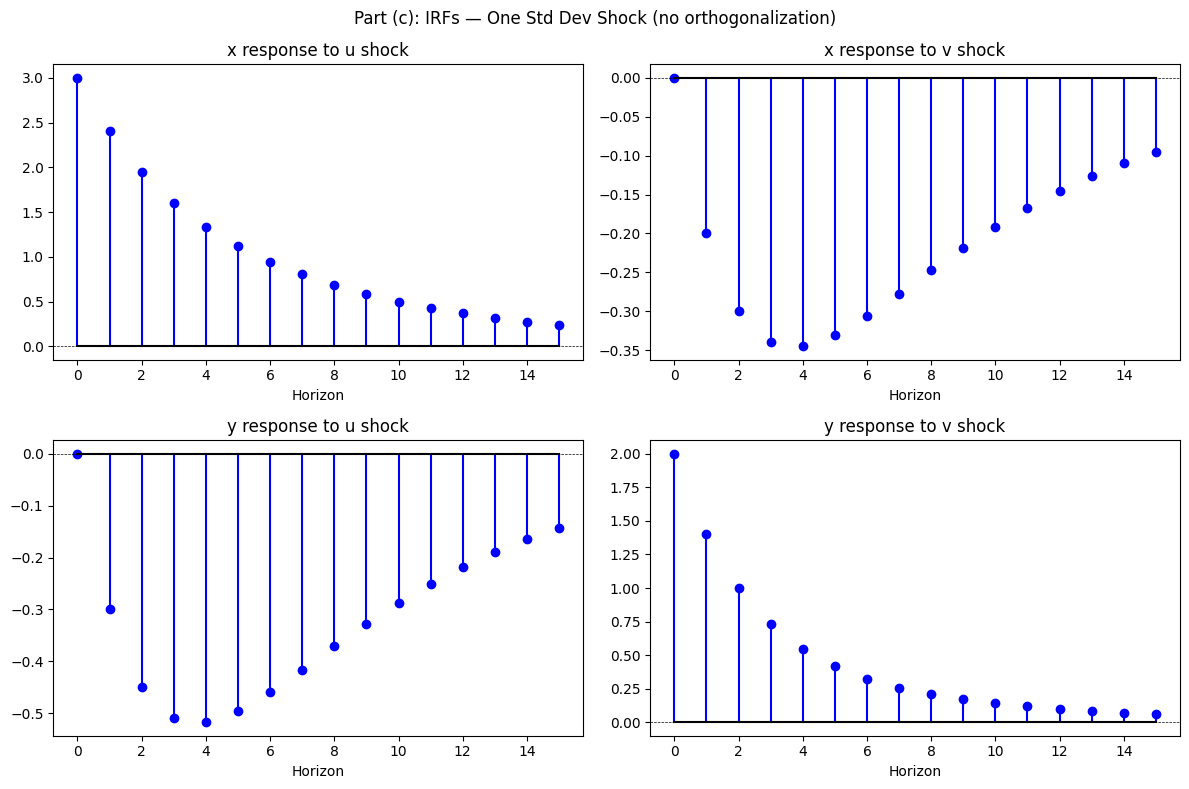

In [5]:
# Part (c): Non-orthogonalized IRFs for 1 std-dev shock
# IRF(k) = A^k * D,  where D = diag(sqrt(Omega_11), sqrt(Omega_22))
D = np.diag([np.sqrt(Omega[0, 0]), np.sqrt(Omega[1, 1])])
K = 16  # horizons 0..15

irf = np.zeros((K, 2, 2))
for k in range(K):
    irf[k] = matrix_power(A, k) @ D

var_names = ['x', 'y']
shock_names = ['u', 'v']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Part (c): IRFs — One Std Dev Shock (no orthogonalization)')
for i in range(2):
    for j in range(2):
        axes[i, j].stem(range(K), irf[:, i, j], linefmt='b-', markerfmt='bo', basefmt='k-')
        axes[i, j].axhline(0, color='k', linewidth=0.5, linestyle='--')
        axes[i, j].set_title(f'{var_names[i]} response to {shock_names[j]} shock')
        axes[i, j].set_xlabel('Horizon')
plt.tight_layout()
plt.show()

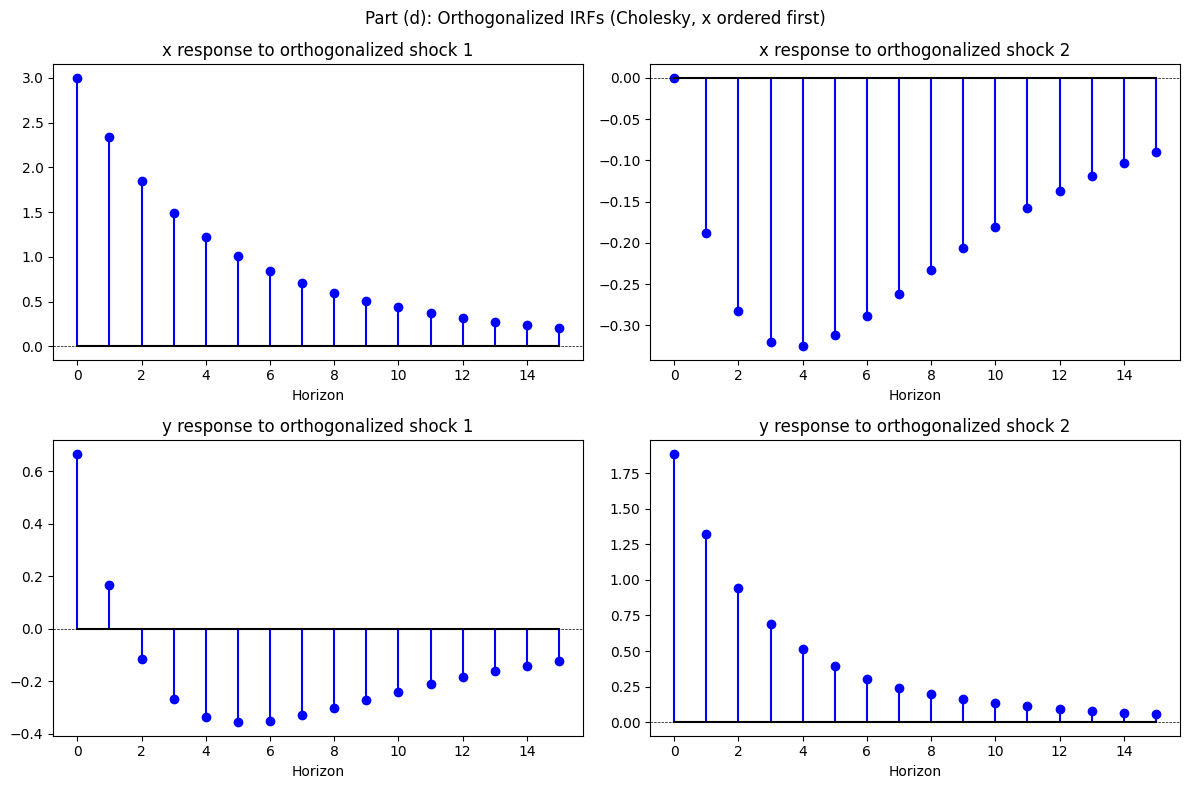

Cholesky factor P =
[[3.         0.        ]
 [0.66666667 1.88561808]]


In [6]:
# Part (d): Orthogonalized IRFs using lower-triangular Cholesky
# Omega = P * P',  IRF(k) = A^k * P
P = cholesky(Omega)  # lower triangular

irf_orth = np.zeros((K, 2, 2))
for k in range(K):
    irf_orth[k] = matrix_power(A, k) @ P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Part (d): Orthogonalized IRFs (Cholesky, x ordered first)')
for i in range(2):
    for j in range(2):
        axes[i, j].stem(range(K), irf_orth[:, i, j], linefmt='b-', markerfmt='bo', basefmt='k-')
        axes[i, j].axhline(0, color='k', linewidth=0.5, linestyle='--')
        axes[i, j].set_title(f'{var_names[i]} response to orthogonalized shock {j+1}')
        axes[i, j].set_xlabel('Horizon')
plt.tight_layout()
plt.show()

print(f"Cholesky factor P =\n{P}")